In [1]:
from utils import *

In [2]:
g_strength = 0.3
EJ = 4.0
EC = 1.5
EL = 0.25
E_osc = 3


qubit_level = 6
osc_level = 50

differential_stark_on_qubit_12_from_osc01  0.005293447724179945
differential_stark_on_qubit_12_from_osc12  0.0008685592844237533
qubit_zero_lamb_on_osc01_12  0.00013303178635437618
qubit_zero_lamb_on_osc01_23  0.00025824205942592826
detunning 01 0.014382853023977127
detunning 02 0.009089405299797182
max overlap^2 2.296568813730389e-12 below threshold for dressed state 298 with eval 155.66532130198812
max overlap^2 5.024930156687139e-11 below threshold for dressed state 299 with eval 156.74456085632053


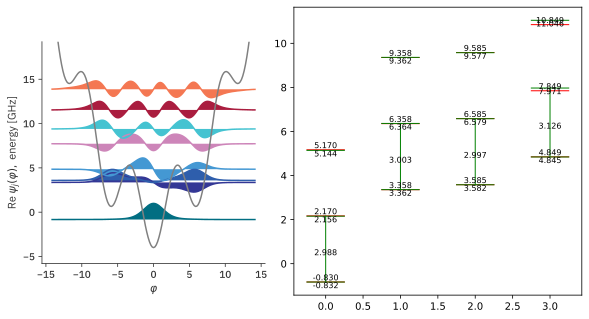

In [19]:
qbt = scqubits.Fluxonium(EJ=EJ,EC=EC,EL=EL,flux=0,cutoff=30,truncated_dim=qubit_level)
osc = scqubits.Oscillator(E_osc=E_osc,truncated_dim=osc_level)
hilbertspace = scqubits.HilbertSpace([qbt, osc])
hilbertspace.add_interaction(g_strength=g_strength,op1=qbt.n_operator,op2=osc.creation_operator,add_hc=True)
hilbertspace.generate_lookup()
product_to_dressed = generate_single_mapping(hilbertspace.hamiltonian())


energies=  hilbertspace.eigenvals(qubit_level*osc_level)
def stark(ql1,ql2,ol):
    return abs(energies[product_to_dressed[(ql2,ol)]]-energies[product_to_dressed[(ql1,ol)]])
def lamb(ol1,ol2,ql):
    return abs(energies[product_to_dressed[(ql,ol2)]]-energies[product_to_dressed[(ql,ol1)]])
def detuning(ql1,ql2):
    return abs((energies[product_to_dressed[(ql1,1)]]-energies[product_to_dressed[(ql1,0)]])  -
                    (energies[product_to_dressed[(ql2,1)]]-energies[product_to_dressed[(ql2,0)]]))
    
differential_stark_on_qubit_12_from_osc01 = abs(stark(1,2,0)-stark(1,2,1)) # For reducing differential phase on off-diagonal elements of the qubit
differential_stark_on_qubit_12_from_osc12 = abs(stark(1,2,1)-stark(1,2,2))
qubit_zero_lamb_on_osc01_12 = abs(lamb(0,1,0)-lamb(1,2,0)) # For easy populating photons
qubit_zero_lamb_on_osc01_23 = abs(lamb(0,1,0)-lamb(2,3,0))
detunning_qubit01 = detuning(0,1) + detuning(0, 2)
print(f"differential_stark_on_qubit_12_from_osc01  {differential_stark_on_qubit_12_from_osc01}")
print(f"differential_stark_on_qubit_12_from_osc12  {differential_stark_on_qubit_12_from_osc12}")
print(f"qubit_zero_lamb_on_osc01_12  {qubit_zero_lamb_on_osc01_12}")
print(f"qubit_zero_lamb_on_osc01_23  {qubit_zero_lamb_on_osc01_23}")
print(f"detunning 01 {detuning(0,1) }")
print(f"detunning 02 {detuning(0,2) }")

plot_specturum(qbt, osc, hilbertspace)

In [4]:
a = hilbertspace.op_in_dressed_eigenbasis(op=osc.annihilation_operator)
a = qutip.Qobj(a[:, :])
 
(evals,) = hilbertspace["evals"]
diag_dressed_hamiltonian = (
        2 * np.pi * qutip.Qobj(np.diag(evals),
        dims=[hilbertspace.subsystem_dims] * 2)
)
diag_dressed_hamiltonian = qutip.Qobj(diag_dressed_hamiltonian[:, :])

leakage_dressed_state_osc_0 = product_to_dressed[(0,0)]
leakage_dressed_state_osc_1 = product_to_dressed[(0,1)]
w_d = transition_frequency(hilbertspace,leakage_dressed_state_osc_0,leakage_dressed_state_osc_1 )
print(w_d)

amp = 0.003
def square_cos(t,*args):
    cos = np.cos(w_d * 2*np.pi * t)
    return  2*np.pi *amp * cos


t_stop = 213 
def square_cos_with_ring_down(t,*args):
    if t > t_stop:
        return 0
    else:
        cos = np.cos(w_d * 2*np.pi * t)
        return  2*np.pi *amp * cos

        
H_with_drive = [
    diag_dressed_hamiltonian,
    [a+a.dag(), square_cos_with_ring_down]]

kappa = 0.07
decay_term = kappa*a

tot_time = 400
tlist = np.linspace(0, tot_time, tot_time)[::4]


state_0_dressed = qutip.basis(hilbertspace.dimension, product_to_dressed[(1,0)])
state_1_dressed = qutip.basis(hilbertspace.dimension, product_to_dressed[(2,0)])
state_plus_dressed = (state_0_dressed + 1j * state_1_dressed).unit()
state_minus_dressed = (state_0_dressed - state_1_dressed).unit()
initial_states  = [state_0_dressed,state_1_dressed,state_plus_dressed,state_minus_dressed ]


existing_chunk_num = 0
for ini_state in initial_states:
    existing_chunk_num = pack_mcsolve_chunks(H = H_with_drive,
                    state0 = ini_state,
                    tlist = tlist,
                    c_ops  = [decay_term],
                    ntraj = 500,
                    existing_chunk_num = existing_chunk_num,
                    chunk_size = 4)

def pack_pkl_files_to_zip(zip_filename="mcsolve_input.zip"):
    # Create a new ZIP file
    with zipfile.ZipFile(zip_filename, 'w', zipfile.ZIP_DEFLATED) as zipf:
        # Loop through all files in the current directory
        for filename in os.listdir('.'):
            # Check if the file is a .pkl file with an integer name
            name, ext = os.path.splitext(filename)
            if ext == '.pkl' and name.isdigit():
                # Add the file to the ZIP
                zipf.write(filename)
                # Delete the .pkl file
                os.remove(filename)
                
pack_pkl_files_to_zip()

2.9881524128281285


In [137]:
# !unzip mcsolve_input.zipx

In [5]:


# List of zip files containing the results
zip_files = [f"mcsolve large dim 4-1.5-0.25-3/result_{i}.zip" for i in range(500)]

# Divide the files into four equal parts
n_parts = 4
part_length = len(zip_files) // n_parts
zip_file_parts = [zip_files[i * part_length: (i + 1) * part_length] for i in range(n_parts)]

# Initialize an empty list to store the four results
results = []

# Merge the results for each part and append to the results list
for part in zip_file_parts:
    results.append(merge_results(part))


done:125/125


In [6]:
import pickle

# Unpickle the dictionary
with open('mcsolve large dim 4-1.5-0.25-3/averaged.pkl', 'wb') as f:
    pickle.dump(results,f)


In [5]:
import pickle

with open('mcsolve large dim 4-1.5-0.25-3/averaged.pkl', 'rb') as f:
    results = pickle.load(f)

In [9]:


interactive_heatmap(results[3], product_to_dressed, qubit_levels=6, oscillator_levels=50)


interactive(children=(IntSlider(value=0, continuous_update=False, description='Time Index:', max=99), Output()…

# 1. Partial trace out qubit, truncate to 2 level

In [10]:

tasks = [(results, 
          f'mcsolve large dim 4-1.5-0.25-3/res_{i}_state_{j}.pkl',
          i, j,  product_to_dressed, qubit_level, osc_level, 1, 2) 
         for i in range(len(results)) 
         for j in range(len(results[i].states))]

from multiprocessing import Pool

with Pool(processes=6) as pool:
    pool.map(compute_and_store_2_level_dm, tasks)

# 2 optimize a phase on the final state and get qutip fidelity for each initial states

In [12]:
zero = qutip.basis(2, 0)
one = qutip.basis(2, 1)

states_ideal  = [zero,
              one,
              (zero + 1j * one).unit(),
              (zero - one).unit() ]


num_initial_states = len(results)
num_time_steps = len(results[0].times)
two_level_states = []
for i in range(num_initial_states) :
    two_level_states.append([])
    for j in range(num_time_steps):
        with open(f'mcsolve large dim 4-1.5-0.25-3/res_{i}_state_{j}.pkl', 'rb') as f:
            state = pickle.load(f)
        two_level_states[-1].append(state)


Text(0.5, 0, 'ns')

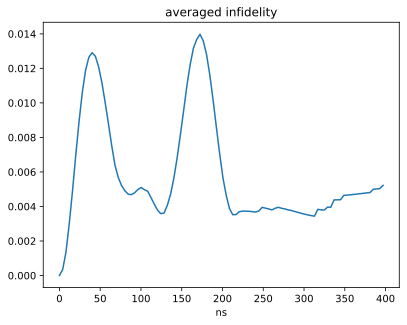

In [13]:


def calc_average_fidelity_with_phase(phase,dms,states_ideal):
    gate = qutip.qip.operations.phasegate(phase)
    fid=[]
    for dm,dm_ideal in zip(dms,states_ideal):
        # new_dm = gate*dm*gate.dag()
        fid.append(qutip.fidelity(dm, gate*dm_ideal))

    return 1-sum(fid)/len(fid)
    




from scipy.optimize import minimize

infidelity = []
phase = []
for idx in range(num_time_steps):
    dms = [states[idx] for states in two_level_states]
    def objective_function(phase):
        return calc_average_fidelity_with_phase(phase[0], dms, states_ideal)
    initial_phase = [0.0]
    bounds = [(0, 2 * 3.141592653589793)]
    opt_result = minimize(objective_function, initial_phase,method="COBYLA")
    infidelity.append(opt_result.fun)
    phase.append(opt_result.x)


plt.plot(results[0].times,infidelity)
plt.title("averaged infidelity")
plt.xlabel("ns")

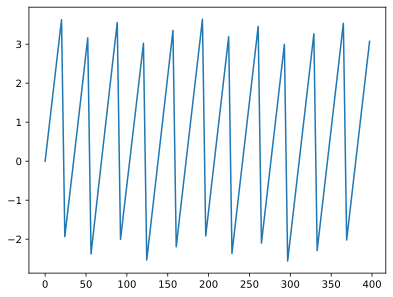

In [14]:
plt.plot(results[0].times,phase,label = f'phase')

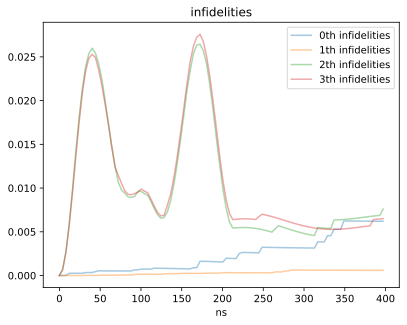

In [15]:
def calc_fidelity_with_phase(phase,dm,state_ideal):
    gate = qutip.qip.operations.phasegate(phase)
    return 1-qutip.fidelity(dm, gate*state_ideal)

    

phases = []
infidelities = []
for i, states in enumerate(two_level_states):
    phases.append([])
    infidelities.append([])
    for idx in range(num_time_steps):
        dm = states[idx]
        def objective_function(params):
            return calc_fidelity_with_phase(params[0], dm, states_ideal[i])
        initial_phase = [0.0]
        opt_result = minimize(objective_function, initial_phase,method="COBYLA")
        phases[-1].append(opt_result.x)
        infidelities[-1].append(opt_result.fun)
for i in range(4):
    plt.plot(results[0].times,infidelities[i],label = f'{i}th infidelities',alpha = 0.4)
plt.title("infidelities")
plt.xlabel("ns")
plt.legend()

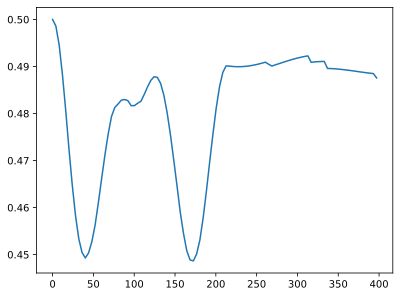

In [16]:
plt.plot(results[0].times,[abs(state.full()[1][0]) for state in two_level_states[2]])